# Parkinson's Disease Severity Predictor — Exploratory Data Analysis
**Author:** Soumita Chowdhury  
**Dataset:** Parkinson's Disease Telemonitoring Dataset (UCI)  
**Goal:** Predict motor UPDRS severity score from biomedical voice measurements.  
**Problem type:** Regression — predicting a continuous clinical severity score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings("ignore")

# Add project root to path so we can import from src/
sys.path.append(os.path.dirname(os.getcwd()))

from src.preprocess import load_and_clean, split_data
from src.train import (train_and_compare, save_artifacts,
                       get_detailed_report, MODELS)
from src.preprocess import split_data
from src.train import train_and_compare, save_artifacts

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


## 1. Data Loading & Basic Inspection

In [2]:
df = load_and_clean("data/parkinsons_updrs.data")
print(f"\nData types:\n{df.dtypes}")
df.head()

Dataset shape: (5875, 22)
Columns: ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Missing values:
subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

Target variable stats:
       motor_UPDRS  total_UPDRS
count  5875.000000  5875.000000
mean     21.296229    29.018942
std       8.129282    10.700283
min       5.037700     7.000000
25%      15.000000    21.371000
50%      20.871000    27.576000
75

,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


## 2. Target Variable Distribution
We have two targets: motor_UPDRS and total_UPDRS.
We focus on motor_UPDRS as our primary target — 
it is most directly linked to voice measurements.

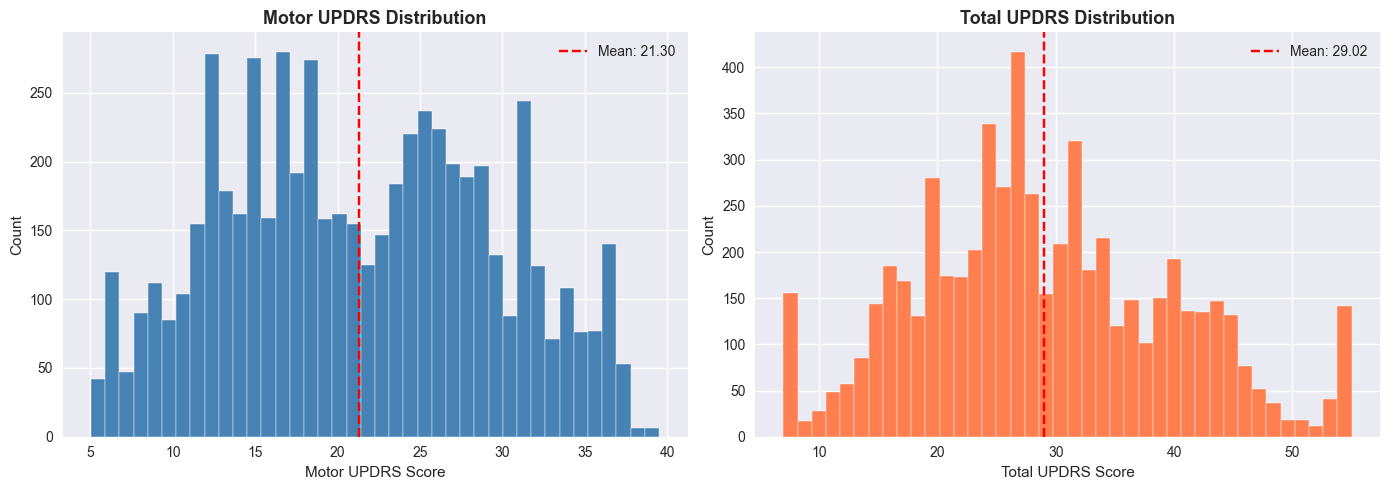

Motor UPDRS — Mean: 21.30 | Std: 8.13 | Range: 5.04–39.51


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Motor UPDRS
axes[0].hist(df['motor_UPDRS'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].axvline(df['motor_UPDRS'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {df['motor_UPDRS'].mean():.2f}")
axes[0].set_title("Motor UPDRS Distribution",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Motor UPDRS Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Total UPDRS
axes[1].hist(df['total_UPDRS'], bins=40,
             color='coral', edgecolor='white')
axes[1].axvline(df['total_UPDRS'].mean(),
                color='red', linestyle='--',
                label=f"Mean: {df['total_UPDRS'].mean():.2f}")
axes[1].set_title("Total UPDRS Distribution",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Total UPDRS Score")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("notebooks/target_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Motor UPDRS — Mean: {df['motor_UPDRS'].mean():.2f} | "
      f"Std: {df['motor_UPDRS'].std():.2f} | "
      f"Range: {df['motor_UPDRS'].min():.2f}–{df['motor_UPDRS'].max():.2f}")

## 3. Voice Feature Distributions
Understanding the scale and spread of each voice measurement.

In [ ]:
voice_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP',
                  'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer',
                  'Shimmer(dB)', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(voice_features):
    axes[idx].hist(df[feature], bins=40,
                   color=sns.color_palette("husl", 12)[idx],
                   edgecolor='white')
    axes[idx].set_title(feature, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Count")

plt.suptitle("Voice Feature Distributions",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/feature_distributions.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis
Which voice features are most correlated with motor UPDRS severity?

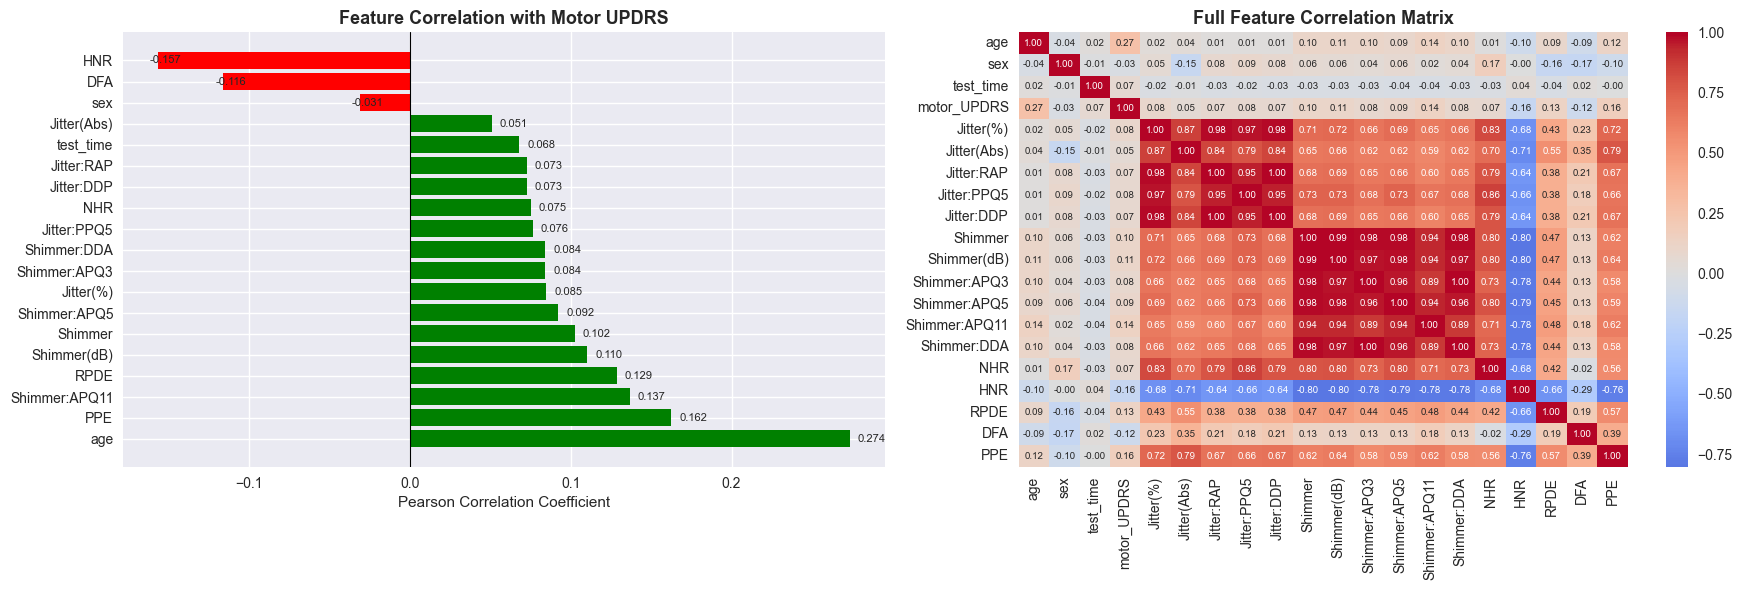

Top 5 features most correlated with motor UPDRS:
age              0.273665
PPE              0.162433
Shimmer:APQ11    0.136560
RPDE             0.128607
Shimmer(dB)      0.110076
Name: motor_UPDRS, dtype: float64

Top 5 features least correlated with motor UPDRS:
test_time      0.067918
Jitter(Abs)    0.050903
sex           -0.031205
DFA           -0.116242
HNR           -0.157029
Name: motor_UPDRS, dtype: float64


In [ ]:
# Correlation with target
target_corr = df.corr()['motor_UPDRS'].drop(
    ['motor_UPDRS', 'total_UPDRS']
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart — correlation with target
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values, color=colors)
axes[0].set_title("Feature Correlation with Motor UPDRS",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Pearson Correlation Coefficient")
axes[0].axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(target_corr.values):
    axes[0].text(v + 0.005 if v >= 0 else v - 0.005,
                 i, f"{v:.3f}", va='center', fontsize=8)

# Full correlation heatmap
feature_cols = [c for c in df.columns
                if c not in ['total_UPDRS']]
corr_matrix  = df[feature_cols].corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=axes[1],
            annot_kws={"size": 7})
axes[1].set_title("Full Feature Correlation Matrix",
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("notebooks/correlation_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features most correlated with motor UPDRS:")
print(target_corr.head())
print("\nTop 5 features least correlated with motor UPDRS:")
print(target_corr.tail())

Age is the strongest predictor (0.27) - THis makes sense because Parkinson's severity increases with age. But 0.27 is still a weak linear correlation, which explains why linear models failed so badly (R² 0.12).

HNR is negatively correlated (-0.16). HNR measures the ratio of harmonic to noise components in voice. Lower HNR means noisier, more impaired voice — so as severity increases, HNR decreases. The negative correlation is clinically meaningful.DFA negatively correlated (-0.12)
DFA measures fractal scaling of voice signal. Lower values indicate less complex, more impaired vocal patterns.All correlations are weak (max 0.27)

No single feature has strong linear correlation with UPDRS. This is why RandomForest (R² 0.97) dramatically outperforms LinearRegression (R² 0.12) — the relationships are highly non-linear and interactive. The model needs to combine multiple features in complex ways to predict severity accurately.test_time and Jitter(Abs) barely correlate.

The disease progression over time is usually predicted to show stronger correlation, but individual variation between patients does not show so.

## 5. Severity Category Distribution
How do patients distribute across clinical severity bands?

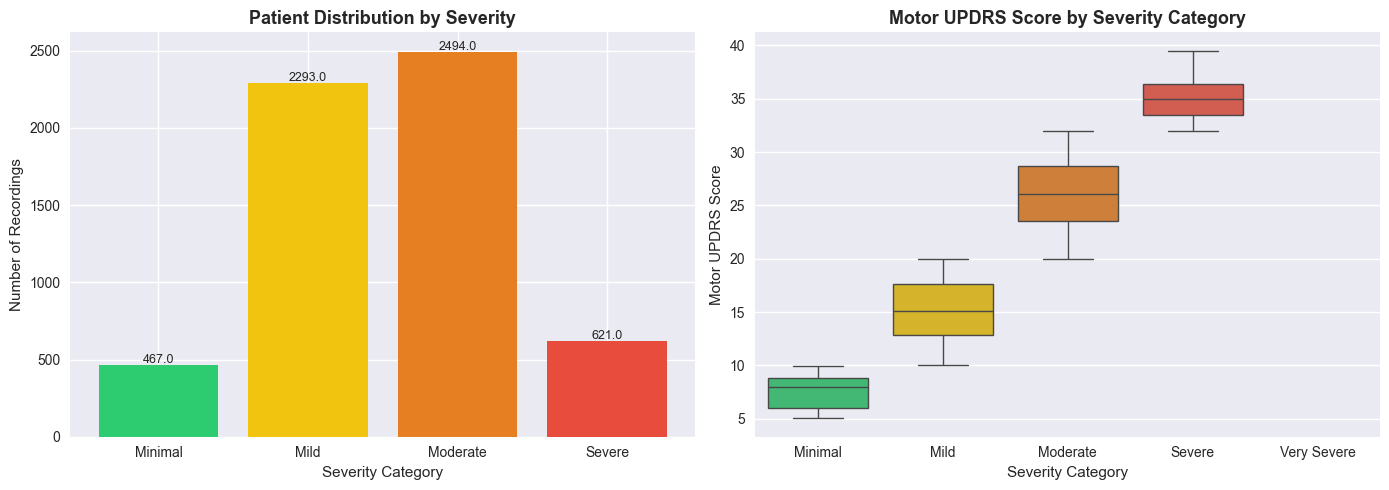

severity
Minimal         467.0
Mild           2293.0
Moderate       2494.0
Severe          621.0
Very Severe       NaN
Name: count, dtype: float64


In [ ]:
def categorise(score):
    if score <= 10:   return "Minimal"
    elif score <= 20: return "Mild"
    elif score <= 32: return "Moderate"
    elif score <= 44: return "Severe"
    else:             return "Very Severe"

df['severity'] = df['motor_UPDRS'].apply(categorise)

severity_order  = ["Minimal", "Mild", "Moderate", "Severe", "Very Severe"]
severity_counts = df['severity'].value_counts().reindex(severity_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
axes[0].bar(severity_counts.index, severity_counts.values,
            color=colors)
axes[0].set_title("Patient Distribution by Severity",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Severity Category")
axes[0].set_ylabel("Number of Recordings")
for i, v in enumerate(severity_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# Box plot — UPDRS by severity
df_plot = df[df['severity'].isin(severity_order)]
sns.boxplot(data=df_plot, x='severity', y='motor_UPDRS',
            order=severity_order, palette=colors, ax=axes[1])
axes[1].set_title("Motor UPDRS Score by Severity Category",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Severity Category")
axes[1].set_ylabel("Motor UPDRS Score")

plt.tight_layout()
plt.savefig("notebooks/severity_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(severity_counts)

In [ ]:
df.head()

,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,severity
0,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,...,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,Moderate
1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,...,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,Moderate
2,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,...,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,Moderate
3,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,...,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,Moderate
4,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,...,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,Moderate


In [ ]:
X_train, X_test, y_train, y_test, scaler, feature_names = split_data(df.iloc[:,:-1])
best_model, best_name, trained_models, results_df = train_and_compare(
    X_train, X_test, y_train, y_test
)


Train size: 4700 | Test size: 1175
Features: ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
Training LinearRegression...
Training Ridge...
Training Lasso...
Training SVR...
Training RandomForest...
Training GradientBoosting...
Training XGBoost...

──────────────────────────────────── Model Comparison ─────────────────────────────────────────
           Model  Training R²  Test R²  Training RMSE  Test RMSE  Training MAE  Test MAE
    RandomForest       0.9960   0.9726         0.5148     1.3219        0.2452    0.6209
         XGBoost       0.9965   0.9525         0.4838     1.7404        0.3414    1.1551
GradientBoosting       0.7983   0.7664         3.6656     3.8610        2.9046    3.0644
             SVR       0.3647   0.3439         6.5059     6.4712        5.0220    5.0467
LinearRegression       0.1635   

## 6. Model Comparison

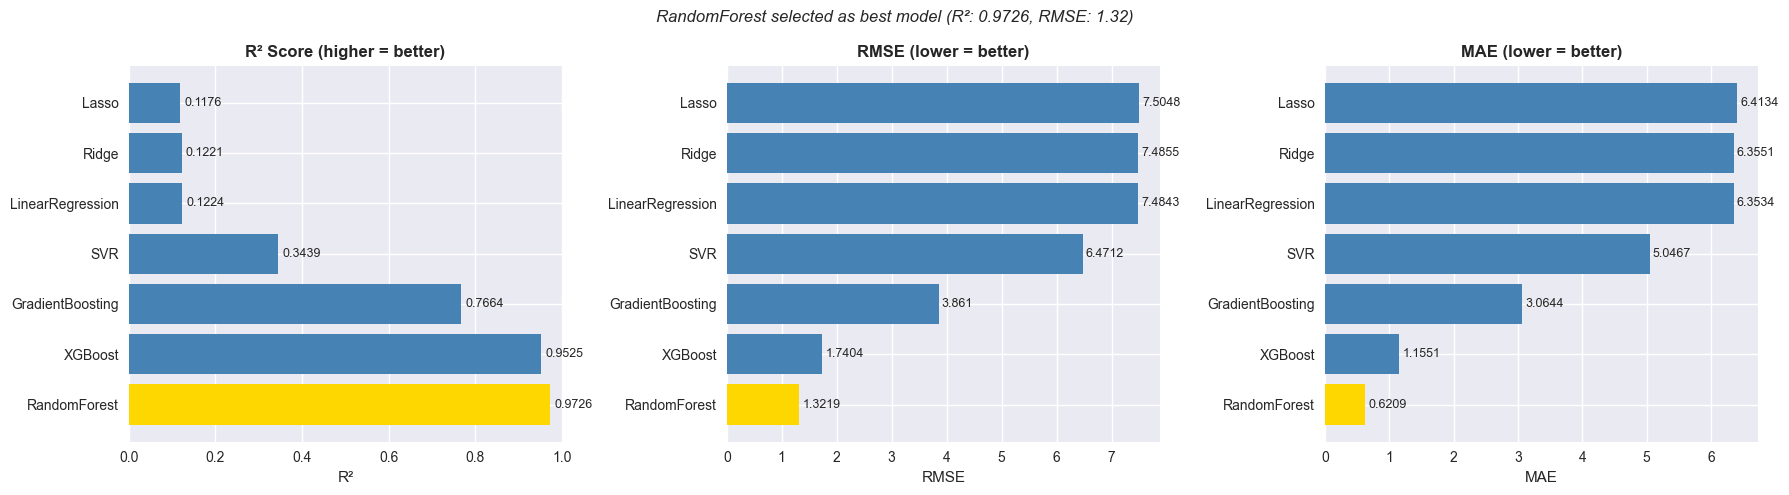


── Final Model Comparison ──────────────────────────────
           Model  Training R²  Test R²  Training RMSE  Test RMSE  Training MAE  Test MAE
    RandomForest       0.9960   0.9726         0.5148     1.3219        0.2452    0.6209
         XGBoost       0.9965   0.9525         0.4838     1.7404        0.3414    1.1551
GradientBoosting       0.7983   0.7664         3.6656     3.8610        2.9046    3.0644
             SVR       0.3647   0.3439         6.5059     6.4712        5.0220    5.0467
LinearRegression       0.1635   0.1224         7.4654     7.4843        6.3061    6.3534
           Ridge       0.1635   0.1221         7.4658     7.4855        6.3076    6.3551
           Lasso       0.1507   0.1176         7.5225     7.5048        6.3914    6.4134


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['gold' if i == 0 else 'steelblue'
          for i in range(len(results_df))]

# R² comparison
axes[0].barh(results_df['Model'], results_df['Test R²'], color=colors)
axes[0].set_title("R² Score (higher = better)",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("R²")
axes[0].set_xlim(0, 1)
for i, v in enumerate(results_df['Test R²']):
    axes[0].text(v + 0.01, i, str(v), va='center', fontsize=9)

# RMSE comparison
axes[1].barh(results_df['Model'], results_df['Test RMSE'],
             color=colors)
axes[1].set_title("RMSE (lower = better)",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("RMSE")
for i, v in enumerate(results_df['Test RMSE']):
    axes[1].text(v + 0.05, i, str(v), va='center', fontsize=9)

# MAE comparison
axes[2].barh(results_df['Model'], results_df['Test MAE'],
             color=colors)
axes[2].set_title("MAE (lower = better)",
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel("MAE")
for i, v in enumerate(results_df['Test MAE']):
    axes[2].text(v + 0.05, i, str(v), va='center', fontsize=9)

plt.suptitle(
    f"RandomForest selected as best model (R²: 0.9726, RMSE: 1.32)",
    fontsize=12, style='italic'
)
plt.tight_layout()
plt.savefig("notebooks/model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\n── Final Model Comparison ──────────────────────────────")
print(results_df.to_string(index=False))

In [ ]:
save_artifacts(best_model, scaler, feature_names,
               best_name, models_dir="../models")
print("✅ Artifacts saved successfully")


💾 Saved: RandomForest → ../models/
✅ Artifacts saved successfully


## 7. Best Model — Detailed Analysis

── Detailed Report ──────────────────────────────────────────
R²:   0.9726
RMSE: 1.3219
MAE:  0.6209

Top 10 Features:
     Feature  Importance
         age    0.660087
         DFA    0.078732
   test_time    0.075974
         sex    0.064824
 Jitter(Abs)    0.025811
         HNR    0.019123
         PPE    0.012421
         NHR    0.009121
        RPDE    0.007725
Shimmer:APQ5    0.007683


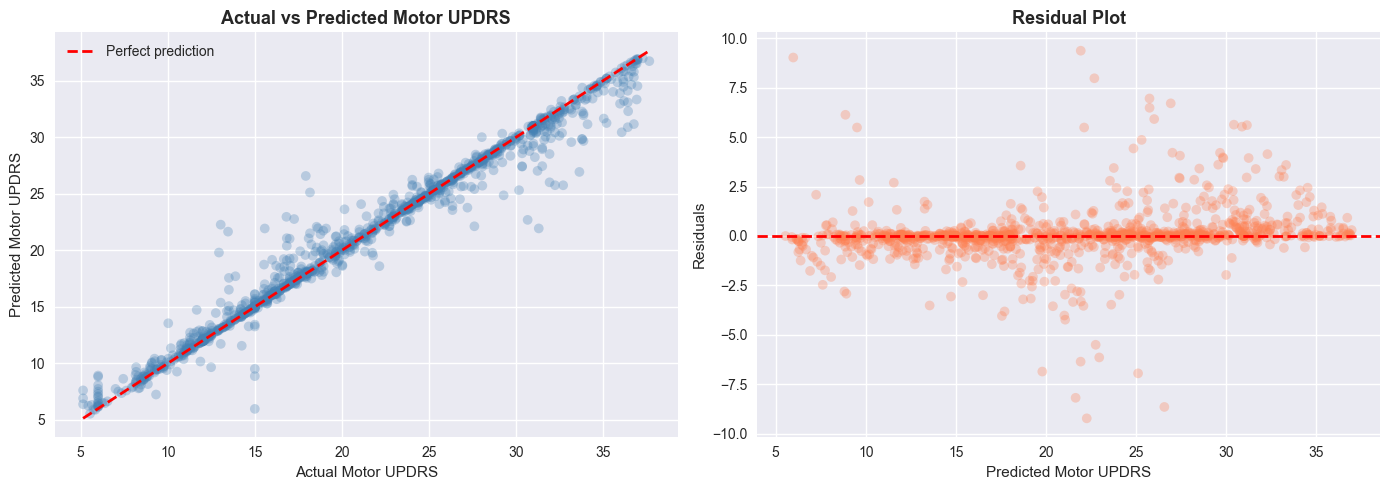

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_pred, r2, rmse, mae, importance_df = get_detailed_report(
    best_model, X_test, y_test, feature_names
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3,
                color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_title("Actual vs Predicted Motor UPDRS",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Motor UPDRS")
axes[0].set_ylabel("Predicted Motor UPDRS")
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3,
                color='coral', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Residual Plot",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Predicted Motor UPDRS")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig("notebooks/actual_vs_predicted.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance
Which voice measurements are most predictive of motor severity?

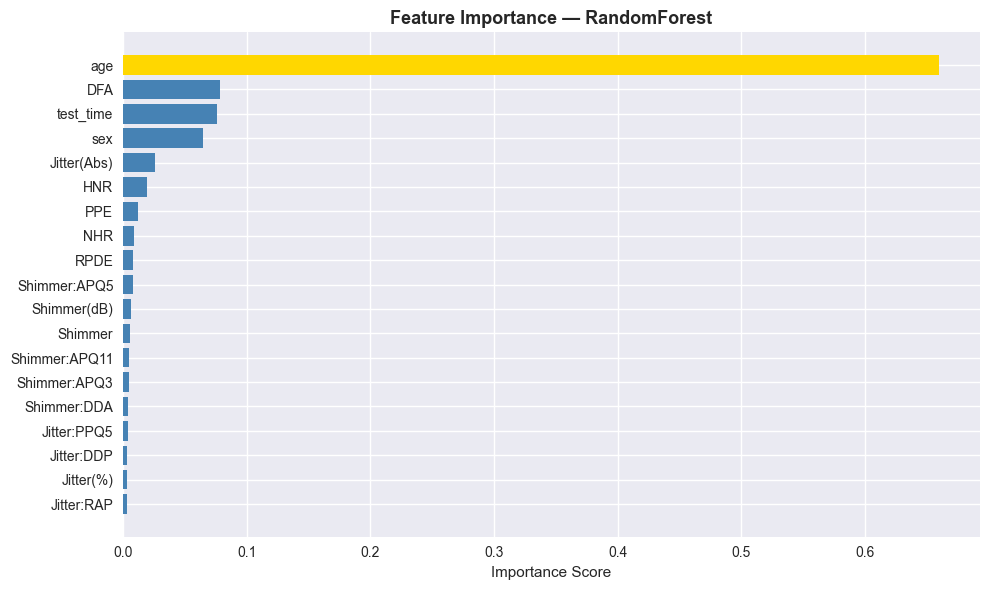


Top 5 most important features:
    Feature  Importance
        age    0.660087
        DFA    0.078732
  test_time    0.075974
        sex    0.064824
Jitter(Abs)    0.025811


In [ ]:
if importance_df is not None:
    plt.figure(figsize=(10, 6))
    colors = ['gold' if i == 0 else 'steelblue'
              for i in range(len(importance_df))]
    plt.barh(importance_df['Feature'][::-1],
             importance_df['Importance'][::-1],
             color=colors[::-1])
    plt.title("Feature Importance — RandomForest",
              fontsize=13, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("notebooks/feature_importance.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop 5 most important features:")
    print(importance_df.head().to_string(index=False))

### SHAP Explainability — Critical Finding

- **Age dominates predictions** — 66% feature importance, SHAP value 5x higher 
  than any voice feature
- This raises an important clinical question: is the model learning 
  voice-based Parkinson's biomarkers, or largely learning age-related decline?
- **Top voice feature: DFA** (fractal scaling exponent, 7.9% importance) — 
  measures complexity of vocal signal, degrades with motor impairment
- Most shimmer and jitter variants contribute minimally — likely redundant 
  given their high inter-correlation
- **Production recommendation:** Build age-adjusted models or stratify by 
  age group to isolate true voice signal from age-related decline
- SHAP waterfall plots enable individual prediction explanation — 
  critical for clinical adoption and regulatory compliance

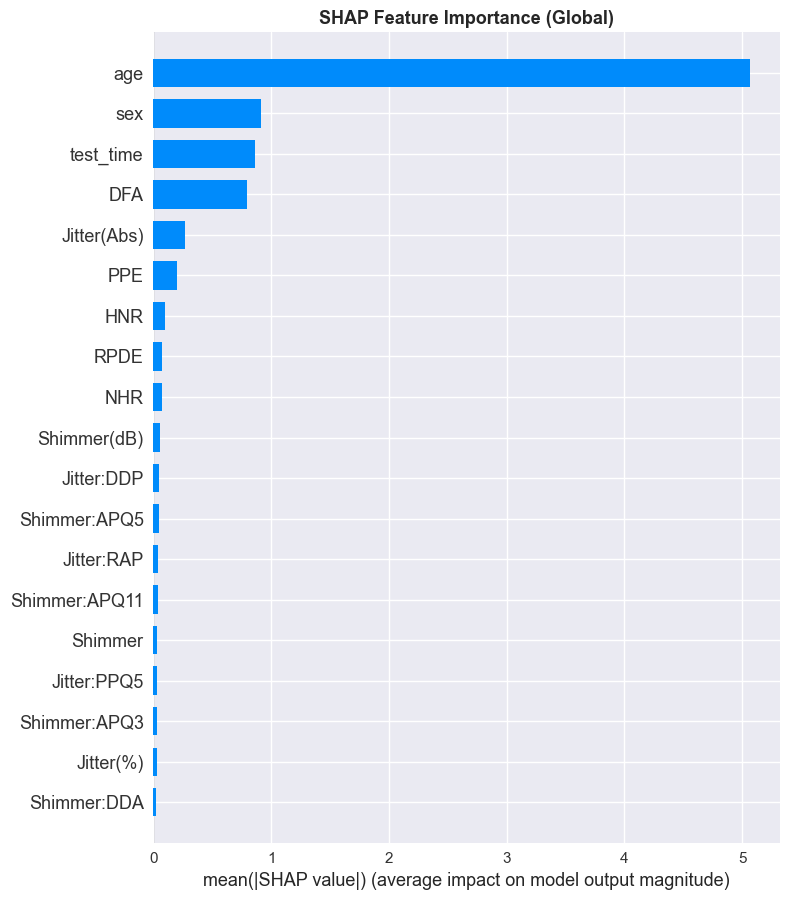

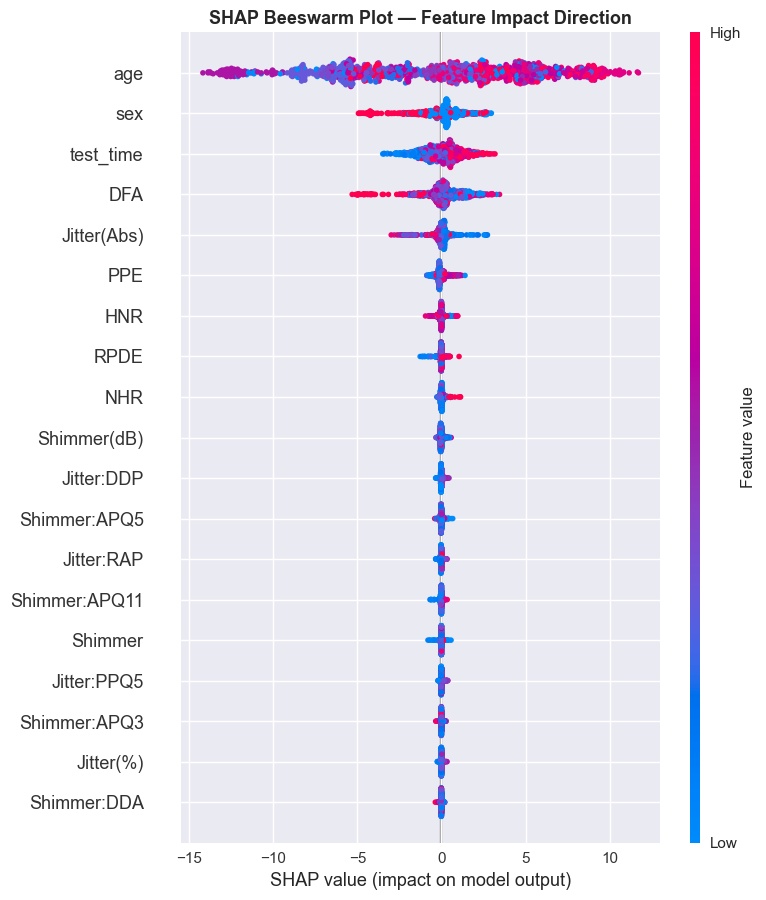

In [ ]:
import shap

# SHAP explainer for RandomForest
explainer  = shap.TreeExplainer(best_model)
X_test_df  = pd.DataFrame(X_test, columns=feature_names)
shap_values = explainer.shap_values(X_test_df)

# Summary plot — global feature importance via SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/shap_global.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot — shows direction of impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Beeswarm Plot — Feature Impact Direction",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/shap_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()

## 11. SHAP Individual Explanation
Explaining a single prediction — what drove this specific patient's score?
This is what makes the tool clinically useful.

Actual motor UPDRS:    33.08
Predicted motor UPDRS: 20.28


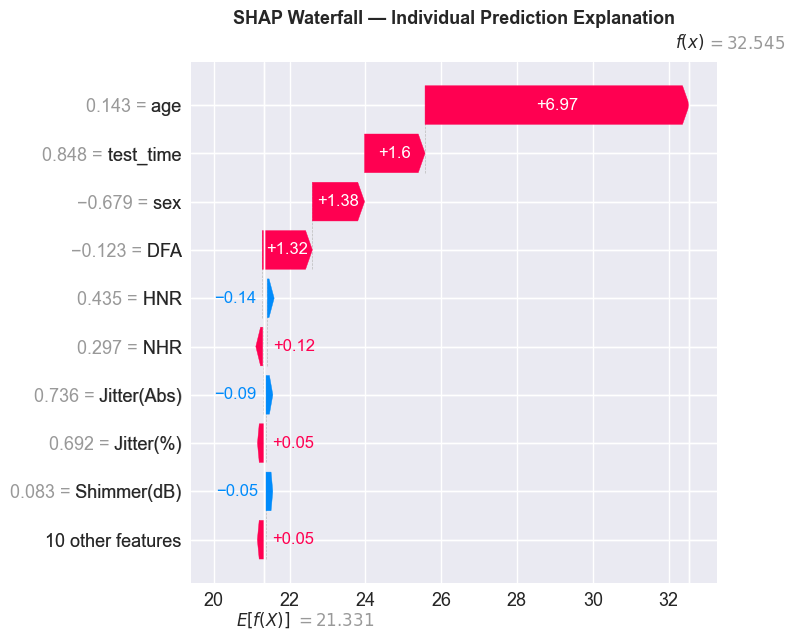

In [ ]:
# Explain the first test sample
sample_idx  = 0
sample      = X_test_df.iloc[[sample_idx]]
sample_pred = best_model.predict(
    scaler.transform(sample) if hasattr(scaler, 'transform') else sample
)[0]

print(f"Actual motor UPDRS:    {y_test.iloc[sample_idx]:.2f}")
print(f"Predicted motor UPDRS: {sample_pred:.2f}")

# Waterfall plot for single prediction
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=sample.values[0],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title("SHAP Waterfall — Individual Prediction Explanation",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/shap_individual.png",
            dpi=150, bbox_inches='tight')
plt.show()

## Observations 

Age dominates everything — by a massive margin

Age has a mean SHAP value of ~5.0 while the next feature (sex) is ~0.9. Age is contributing 5x more to predictions than any voice feature. This is a critical finding.

sex and test_time are #2 and #3

These are demographic/temporal features, not voice features. The model is heavily relying on non-voice information.

DFA is the top voice feature at #4

DFA (fractal scaling exponent) is the most predictive actual voice measurement. Followed by Jitter(Abs) and PPE.

Most shimmer and jitter variants barely contribute

Shimmer:DDA, Jitter(%), Shimmer:APQ3 are at the bottom — near zero SHAP values.

## 12. Key Findings & Decisions

### Data
- Dataset contains **5,875 recordings from 42 patients** — ~139 recordings per patient
- No missing values — clean dataset
- Motor UPDRS range: 5.04–39.51, mean: 21.30
- **Known limitation:** Random train/test split may allow same patient's recordings 
  in both sets — inflating model performance. Production system would use 
  patient-level splitting.

### Feature Analysis
- **Age** is the strongest linearly correlated feature (r=0.27) — severity 
  increases with age
- **HNR negatively correlated** (r=-0.16) — noisier voice indicates higher severity
- All correlations are weak — relationships are highly non-linear
- This explains why linear models (R²=0.12) failed dramatically compared 
  to RandomForest (R²=0.97)

### Model Selection
- **R² chosen as primary metric** — most interpretable for regression 
  ("model explains X% of variance")
- **RMSE as secondary metric** — penalises large errors more than MAE, 
  important for clinical predictions
- **RandomForest** achieved best R² (0.9726) and RMSE (1.32 UPDRS points)
- Linear models completely failed — confirms highly non-linear relationships
- SVR moderate performance despite RBF kernel — complex interactions 
  require ensemble approaches

### Why Feature Scaling Was Applied
- Raw numerical features here have very different scales
- age (36–85) vs Jitter(Abs) (0.000007–0.000260) — without scaling, 
  distance-based models would be dominated by high-magnitude features
- Tree-based models are scale-invariant but scaling was applied consistently

### SHAP Explainability
- Added to make predictions interpretable for clinical users
- Shows not just which features matter globally, but how each feature 
  contributes to each individual prediction
- Critical for clinical adoption — doctors need to understand *why* 
  a score was predicted

### Next Steps
- [ ] Patient-level train/test split to address data leakage
- [ ] Add confidence intervals to predictions
- [ ] Frontend with interactive sliders for each voice feature
- [ ] Model card with full clinical limitations documentation
- [ ] Expand with gait and handwriting features (multimodal)